### Comparison on what points are most suitable - Train a model with many points 

In [15]:
import os
import json
import shutil
import pickle
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization, Bidirectional, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from keras.utils import plot_model
from collections import Counter

import random


In [51]:
# # Set seed for Python's built-in random module
# random.seed(42)

# # Set seed for NumPy
# np.random.seed(42)

# # Set seed for TensorFlow
# tf.random.set_seed(42)

In [52]:
# check if the gpu support available
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
data_directory = '../all_outputs/output_ssl_small/'

# list all the files in directories and sub directories in in data_direcotiry and store them list_list list
file_names = []

for root, _, files in os.walk(data_directory):  # Walk through all directories and subdirectories
        for filename in files:
            file_names.append(os.path.join(root, filename))

print(len(file_names))            

3115


In [19]:
# Define indices for points of interest
pose_indices_1 = [0, 2, 5, 7, 8, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
hand_indices_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


pose_indices_2 = [0, 15, 16, 17, 18, 19, 20]
hand_indices_2 = [0, 4, 7, 8, 11, 12, 15, 16, 19, 20]

In [20]:

def load_landmarks(filenames, num_frames, glossIndex = 4, useSelectedIndices = False):
    pose_indices = pose_indices_1
    hand_indices = hand_indices_1

    if useSelectedIndices:
        print("Using selected indices")
        pose_indices = pose_indices_2
        hand_indices = hand_indices_2

    
    
    # Prepare storage for data and labels
    video_data = []
    labels = []
    
    for file in filenames:
     
        # print(file)
        gloss = file.split('/')[glossIndex]
        # print(gloss)


        with open(file, 'rb') as f:
                landmarks = pickle.load(f)
                    
                # Prepare frame storage for each video with fixed number of frames
                frames = []

                # Get frame sampling step (skip frames if necessary)
                total_frames = len(landmarks)
                step = max(1, total_frames // num_frames)
                    
                # Process frames
                for i in range(num_frames):
                    frame_index = i * step if total_frames >= num_frames else i
                    
                    if frame_index < total_frames:
                        frame = landmarks[frame_index]
                    else:
                        frame = None
                        
                    # Extract and flatten required points
                    pose_points = frame['pose_landmarks'] if frame and frame['pose_landmarks'] else [None] * 33
                    left_hand_points = frame['left_hand_landmarks'] if frame and frame['left_hand_landmarks'] else [None] * 21
                    right_hand_points = frame['right_hand_landmarks'] if frame and frame['right_hand_landmarks'] else [None] * 21
                        
                    # Collect only specified indices and flatten them
                    extracted_points = []

                    # Collect pose points first
                    for idx in pose_indices:
                        point = pose_points[idx] if pose_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])
                        
                    # print(left_hand_points)
                    for idx in hand_indices:
                        point = left_hand_points[idx] if left_hand_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])

                    # Collect right hand points
                    for idx in hand_indices:
                        point = right_hand_points[idx] if right_hand_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])
                        
                    frames.append(extracted_points)
                    
                # Add the processed video frames to the main array
                video_data.append(frames)
                labels.append(gloss)
                

    # Convert to numpy arrays
    video_data = np.array(video_data)
    labels = np.array(labels)
    
    return video_data, labels

# Example usage
num_frames = 30  # Desired fixed number of frames per video

video_data, labels = load_landmarks(file_names, num_frames, 3)

# `video_data` has shape (number of videos, num_frames, number of points*2) where points*2 is the flattened landmark count
# `labels` contains the labels for each video


In [21]:
NUM_CLASSES = len(set(labels))
NUM_CLASSES

64

In [78]:
CUSTOM_NUM_CLASSES = NUM_CLASSES


# Count the occurrences of each class
class_counts = Counter(labels)

# Sort classes by their counts in descending order and select the top 120 classes
top_classes = [cls for cls, count in class_counts.most_common(CUSTOM_NUM_CLASSES)]

# Filter the dataset to keep only the samples belonging to the top 120 classes
filtered_indices = [i for i, label in enumerate(labels) if label in top_classes]
video_data_filtered = video_data[filtered_indices]
labels_filtered = labels[filtered_indices]

# Encode labels after filtering
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels_filtered)
labels_one_hot = to_categorical(labels_encoded, num_classes=len(top_classes))

# Split dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(video_data_filtered, labels_one_hot, test_size=0.65, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print train, val, test shapes
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

# Print average number of instance per class in traning set
class_counts = Counter(y_train.argmax(axis=1))
print("Average number of instance per class in traning set")
print(sum(class_counts.values()) / len(class_counts))

NUM_CLASSES = CUSTOM_NUM_CLASSES


(1090, 30, 122) (1090, 64)
(1012, 30, 122) (1012, 64)
(1013, 30, 122) (1013, 64)
Average number of instance per class in traning set
17.03125


In [79]:
def augment_data(x):
    # Add random noise to the input
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=0.01)
    return x + noise

In [80]:

# Apply augmentation during training
X_train_augmented = augment_data(X_train)

print(X_train_augmented.shape, y_train.shape)

(1090, 30, 122) (1090, 64)


In [65]:
# input_shape=(num_frames, len(pose_indices) * 2 + len(hand_indices) * 2 * 2)

In [81]:
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers


class PositionEmbedding(layers.Layer):
    def __init__(self, config):
        super(PositionEmbedding, self).__init__()
        self.position_embeddings = self.add_weight(
            name="position_embeddings",
            shape=(config.max_position_embeddings, config.hidden_size),
            initializer="random_normal",
            trainable=True,
        )
    
    def call(self, x):
        seq_length = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_length, delta=1)
        position_embeddings = tf.gather(self.position_embeddings, positions)
        return x + position_embeddings


class Transformer(Model):
    def __init__(self, config, n_classes=50, freeze_pretrained=False):
        super(Transformer, self).__init__()
        self.l1 = layers.Dense(config.hidden_size, activation=None, kernel_regularizer=regularizers.l2(0.001))
        self.embedding = PositionEmbedding(config)
        
        # Transformer layers
        self.transformer_layers = [
            layers.MultiHeadAttention(
                num_heads=config.num_attention_heads, 
                key_dim=config.hidden_size // config.num_attention_heads,
                kernel_regularizer=regularizers.l2(0.001)
            )
            for _ in range(config.num_hidden_layers)
        ]
        
        # Layer normalization
        self.layer_norms = [
            layers.LayerNormalization(epsilon=1e-6)
            for _ in range(config.num_hidden_layers)
        ]
        
        # Final classification layer (will be replaced during fine-tuning)
        self.l2 = layers.Dense(n_classes, activation=None, kernel_regularizer=regularizers.l2(0.001))
        self.dropout = layers.Dropout(0.3)
        
        # Optionally freeze pretrained layers
        if freeze_pretrained:
            for layer in [self.l1, self.embedding] + self.transformer_layers + self.layer_norms:
                layer.trainable = False

    def call(self, x, training=False):
        x = self.l1(x)
        x = self.embedding(x)
        
        for i, layer in enumerate(self.transformer_layers):
            x = layer(x, x)  # Self-attention
            x = self.layer_norms[i](x)  # Apply LayerNormalization
        
        x = tf.reduce_max(x, axis=1)  # Global max pooling
        x = self.dropout(x, training=training)
        x = self.l2(x)
        return x

In [82]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop if no improvement for 10 epochs
    restore_best_weights=True  # Restore weights from the best epoch
)

In [89]:
# Configuration
feature = X_train_augmented.shape[2]
print("Features: ", feature)

class Config:
    input_size = feature  # 33 skeleton points, each with (x, y)
    hidden_size = 128
    num_hidden_layers = 4
    num_attention_heads = 8
    max_position_embeddings = 30  # Maximum number of frames
    num_classes = NUM_CLASSES  # Number of output classes

config = Config()

# Build the model
model = Transformer(config, n_classes=config.num_classes)

# Print the model summary
model.build(input_shape=(None, config.max_position_embeddings, config.input_size))
model.summary()

Features:  122
Model: "transformer_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_28 (Dense)            multiple                  15744     
                                                                 
 position_embedding_14 (Pos  multiple                  3840      
 itionEmbedding)                                                 
                                                                 
 multi_head_attention_56 (M  multiple                  66048     
 ultiHeadAttention)                                              
                                                                 
 multi_head_attention_57 (M  multiple                  66048     
 ultiHeadAttention)                                              
                                                                 
 multi_head_attention_58 (M  multiple                  66048     
 ultiHeadAttention)                  

In [90]:
# # Compile the model
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#               loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True, label_smoothing=0.1),
#               metrics=['accuracy'])

# # Train model
# history = model.fit(
#     X_train_augmented, 
#     y_train, 
#     validation_data=(X_val, y_val), 
#     epochs=250, 
#     batch_size=32, 
#     callbacks=[early_stopping],
#     )

# # Evaluate on the test set
# test_loss, test_accuracy = model.evaluate(X_test, y_test)
# print(f"Test Accuracy: {test_accuracy:.4f}")




# # Save label encoder and model if needed
# # joblib.dump(label_encoder, 'label_encoder.pkl')
# # model.save('lstm_landmark_model.h5')


### =======================================================================

# Convert one-hot encoded labels to class indices
y_train_indices = np.argmax(y_train, axis=1)
y_val_indices = np.argmax(y_val, axis=1)
y_test_indices = np.argmax(y_test, axis=1)

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),  # Unique class indices
    y=y_train_indices                     # Class indices for training data
)
class_weights = dict(enumerate(class_weights))  # Convert to dictionary

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True, label_smoothing=0.1),
    metrics=['accuracy']
)

# Train the model with class weights
history = model.fit(
    X_train_augmented, 
    y_train, 
    validation_data=(X_val, y_val), 
    epochs=100, 
    batch_size=32, 
    # callbacks=[early_stopping],
    class_weight=class_weights,
)

# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

Epoch 1/100
35/35 [==============================] - 10s 29ms/step - loss: 5.1040 - accuracy: 0.0138 - val_loss: 4.5719 - val_accuracy: 0.0277
Epoch 2/100
35/35 [==============================] - 1s 15ms/step - loss: 4.8259 - accuracy: 0.0248 - val_loss: 4.3892 - val_accuracy: 0.0435
Epoch 3/100
35/35 [==============================] - 1s 15ms/step - loss: 4.6730 - accuracy: 0.0275 - val_loss: 4.3195 - val_accuracy: 0.0385
Epoch 4/100
35/35 [==============================] - 1s 16ms/step - loss: 4.5356 - accuracy: 0.0321 - val_loss: 4.1756 - val_accuracy: 0.0415
Epoch 5/100
35/35 [==============================] - 1s 15ms/step - loss: 4.4559 - accuracy: 0.0422 - val_loss: 4.1357 - val_accuracy: 0.0563
Epoch 6/100
35/35 [==============================] - 1s 15ms/step - loss: 4.3921 - accuracy: 0.0495 - val_loss: 4.0956 - val_accuracy: 0.0741
Epoch 7/100
35/35 [==============================] - 1s 16ms/step - loss: 4.2750 - accuracy: 0.0550 - val_loss: 4.0460 - val_accuracy: 0.0741
Epoch

In [65]:
# model_path = '../saved_models/book_9/pretrained_model_weights.h5'

In [66]:
# model.save_weights(model_path)

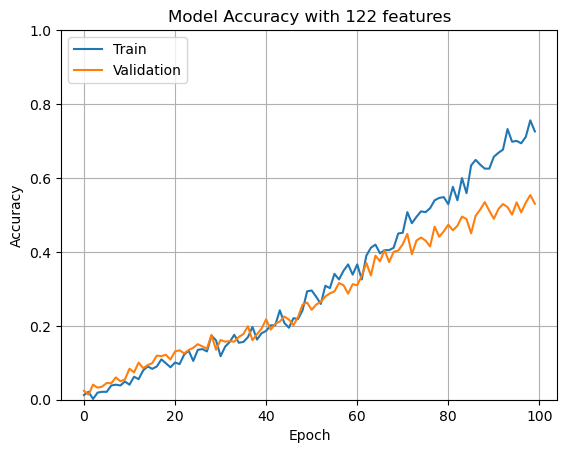

In [53]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy with ' + str(feature) + ' features')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.ylim(0, 1)
plt.grid(True)
plt.legend(['Train', 'Validation'], loc='upper left')
save_plt = plt
plt.show()


In [91]:
# Calculate F1 score and other parameters
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

f1 = f1_score(y_test.argmax(axis=1), y_pred_classes, average='weighted')
precision = precision_score(y_test.argmax(axis=1), y_pred_classes, average='weighted')
recall = recall_score(y_test.argmax(axis=1), y_pred_classes, average='weighted')
accuracy = accuracy_score(y_test.argmax(axis=1), y_pred_classes)

print("F1 Score of Model 2:", f1)
print("Precision of Model 2:", precision)
print("Recall of Model 2:", recall)
print("Accuracy of Model 2:", accuracy)



32/32 [==============================] - 0s 2ms/step
F1 Score of Model 2: 0.7734587045172621
Precision of Model 2: 0.7977238847555004
Recall of Model 2: 0.7769002961500494
Accuracy of Model 2: 0.7769002961500494


In [69]:
print(X_test.shape)

(754, 30, 122)


24/24 [==============================] - 0s 5ms/step


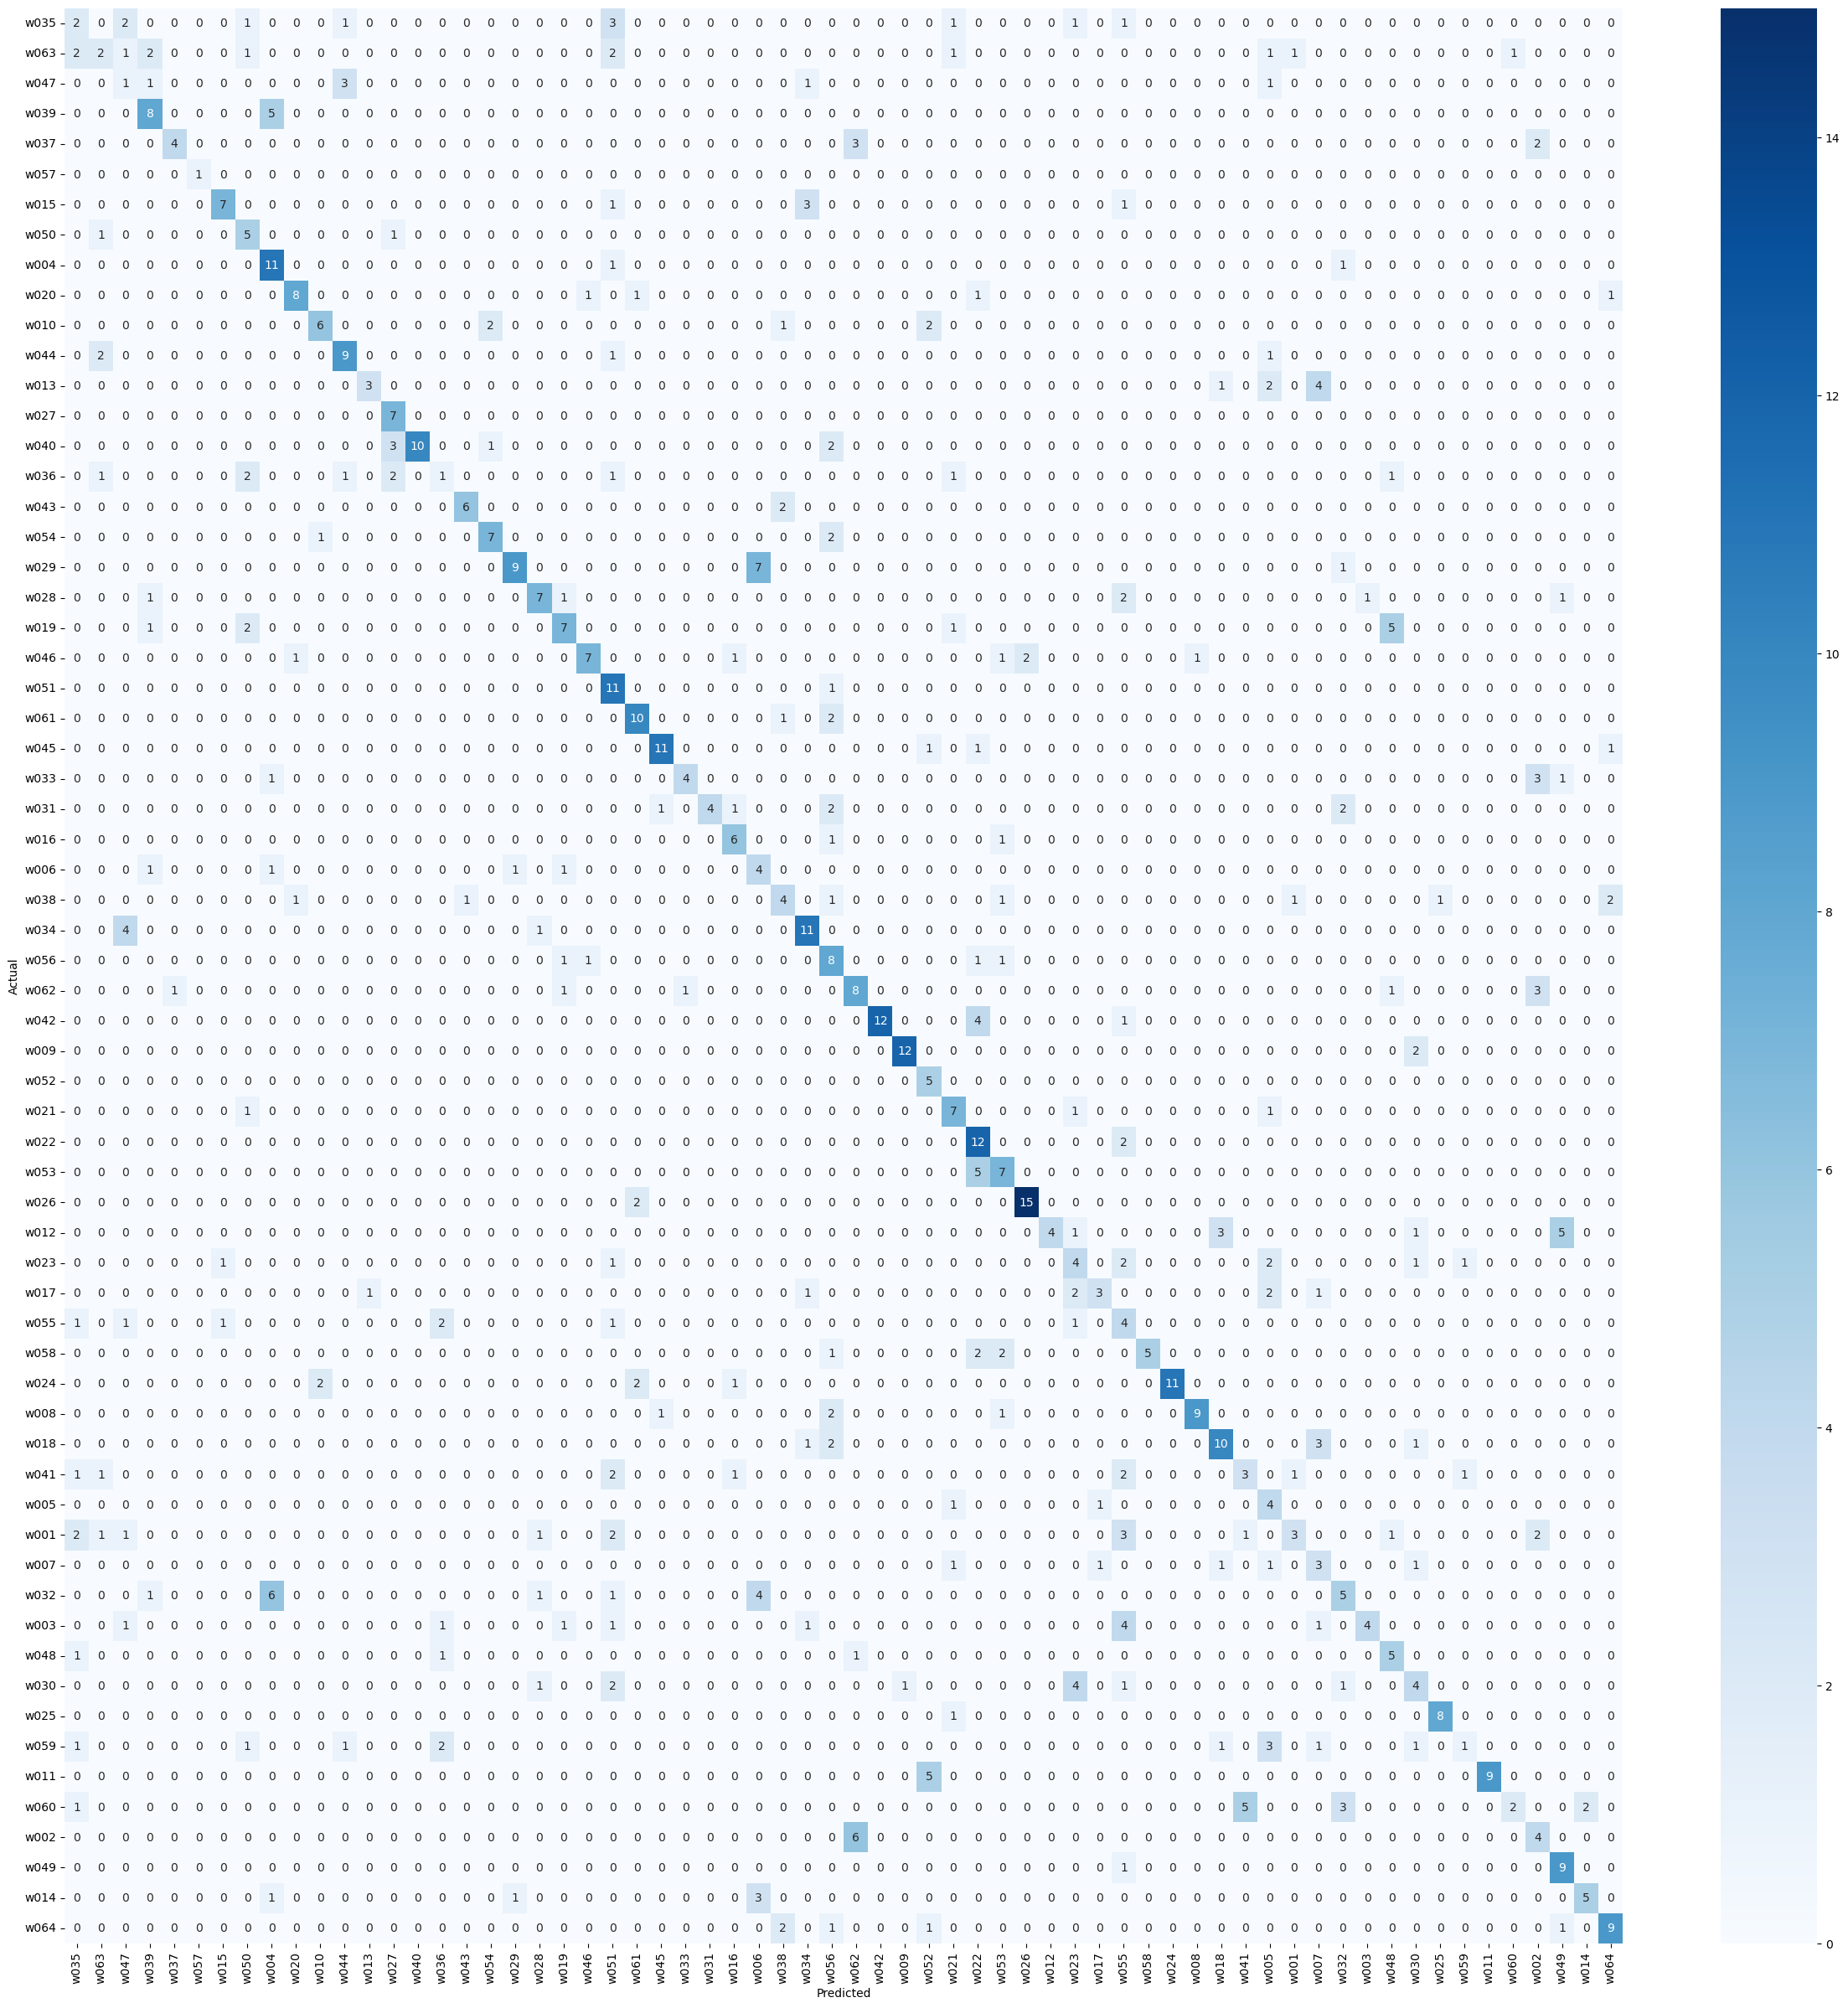

In [70]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test.argmax(axis=1), y_pred_classes)
plt.figure(figsize=(30, 30))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(top_classes), yticklabels=set(top_classes))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

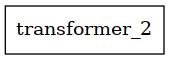

In [71]:
# plot model architecture
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

24/24 [==============================] - 0s 3ms/step


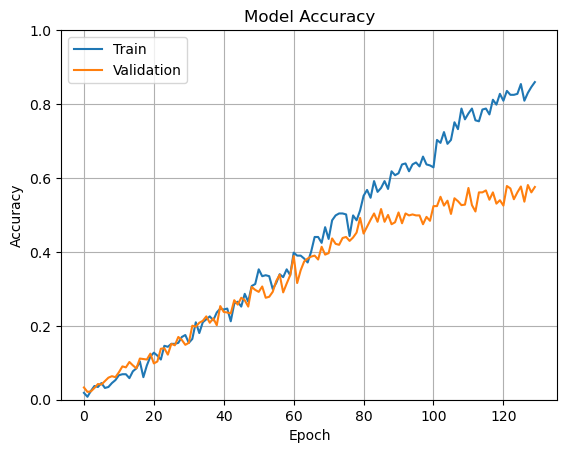

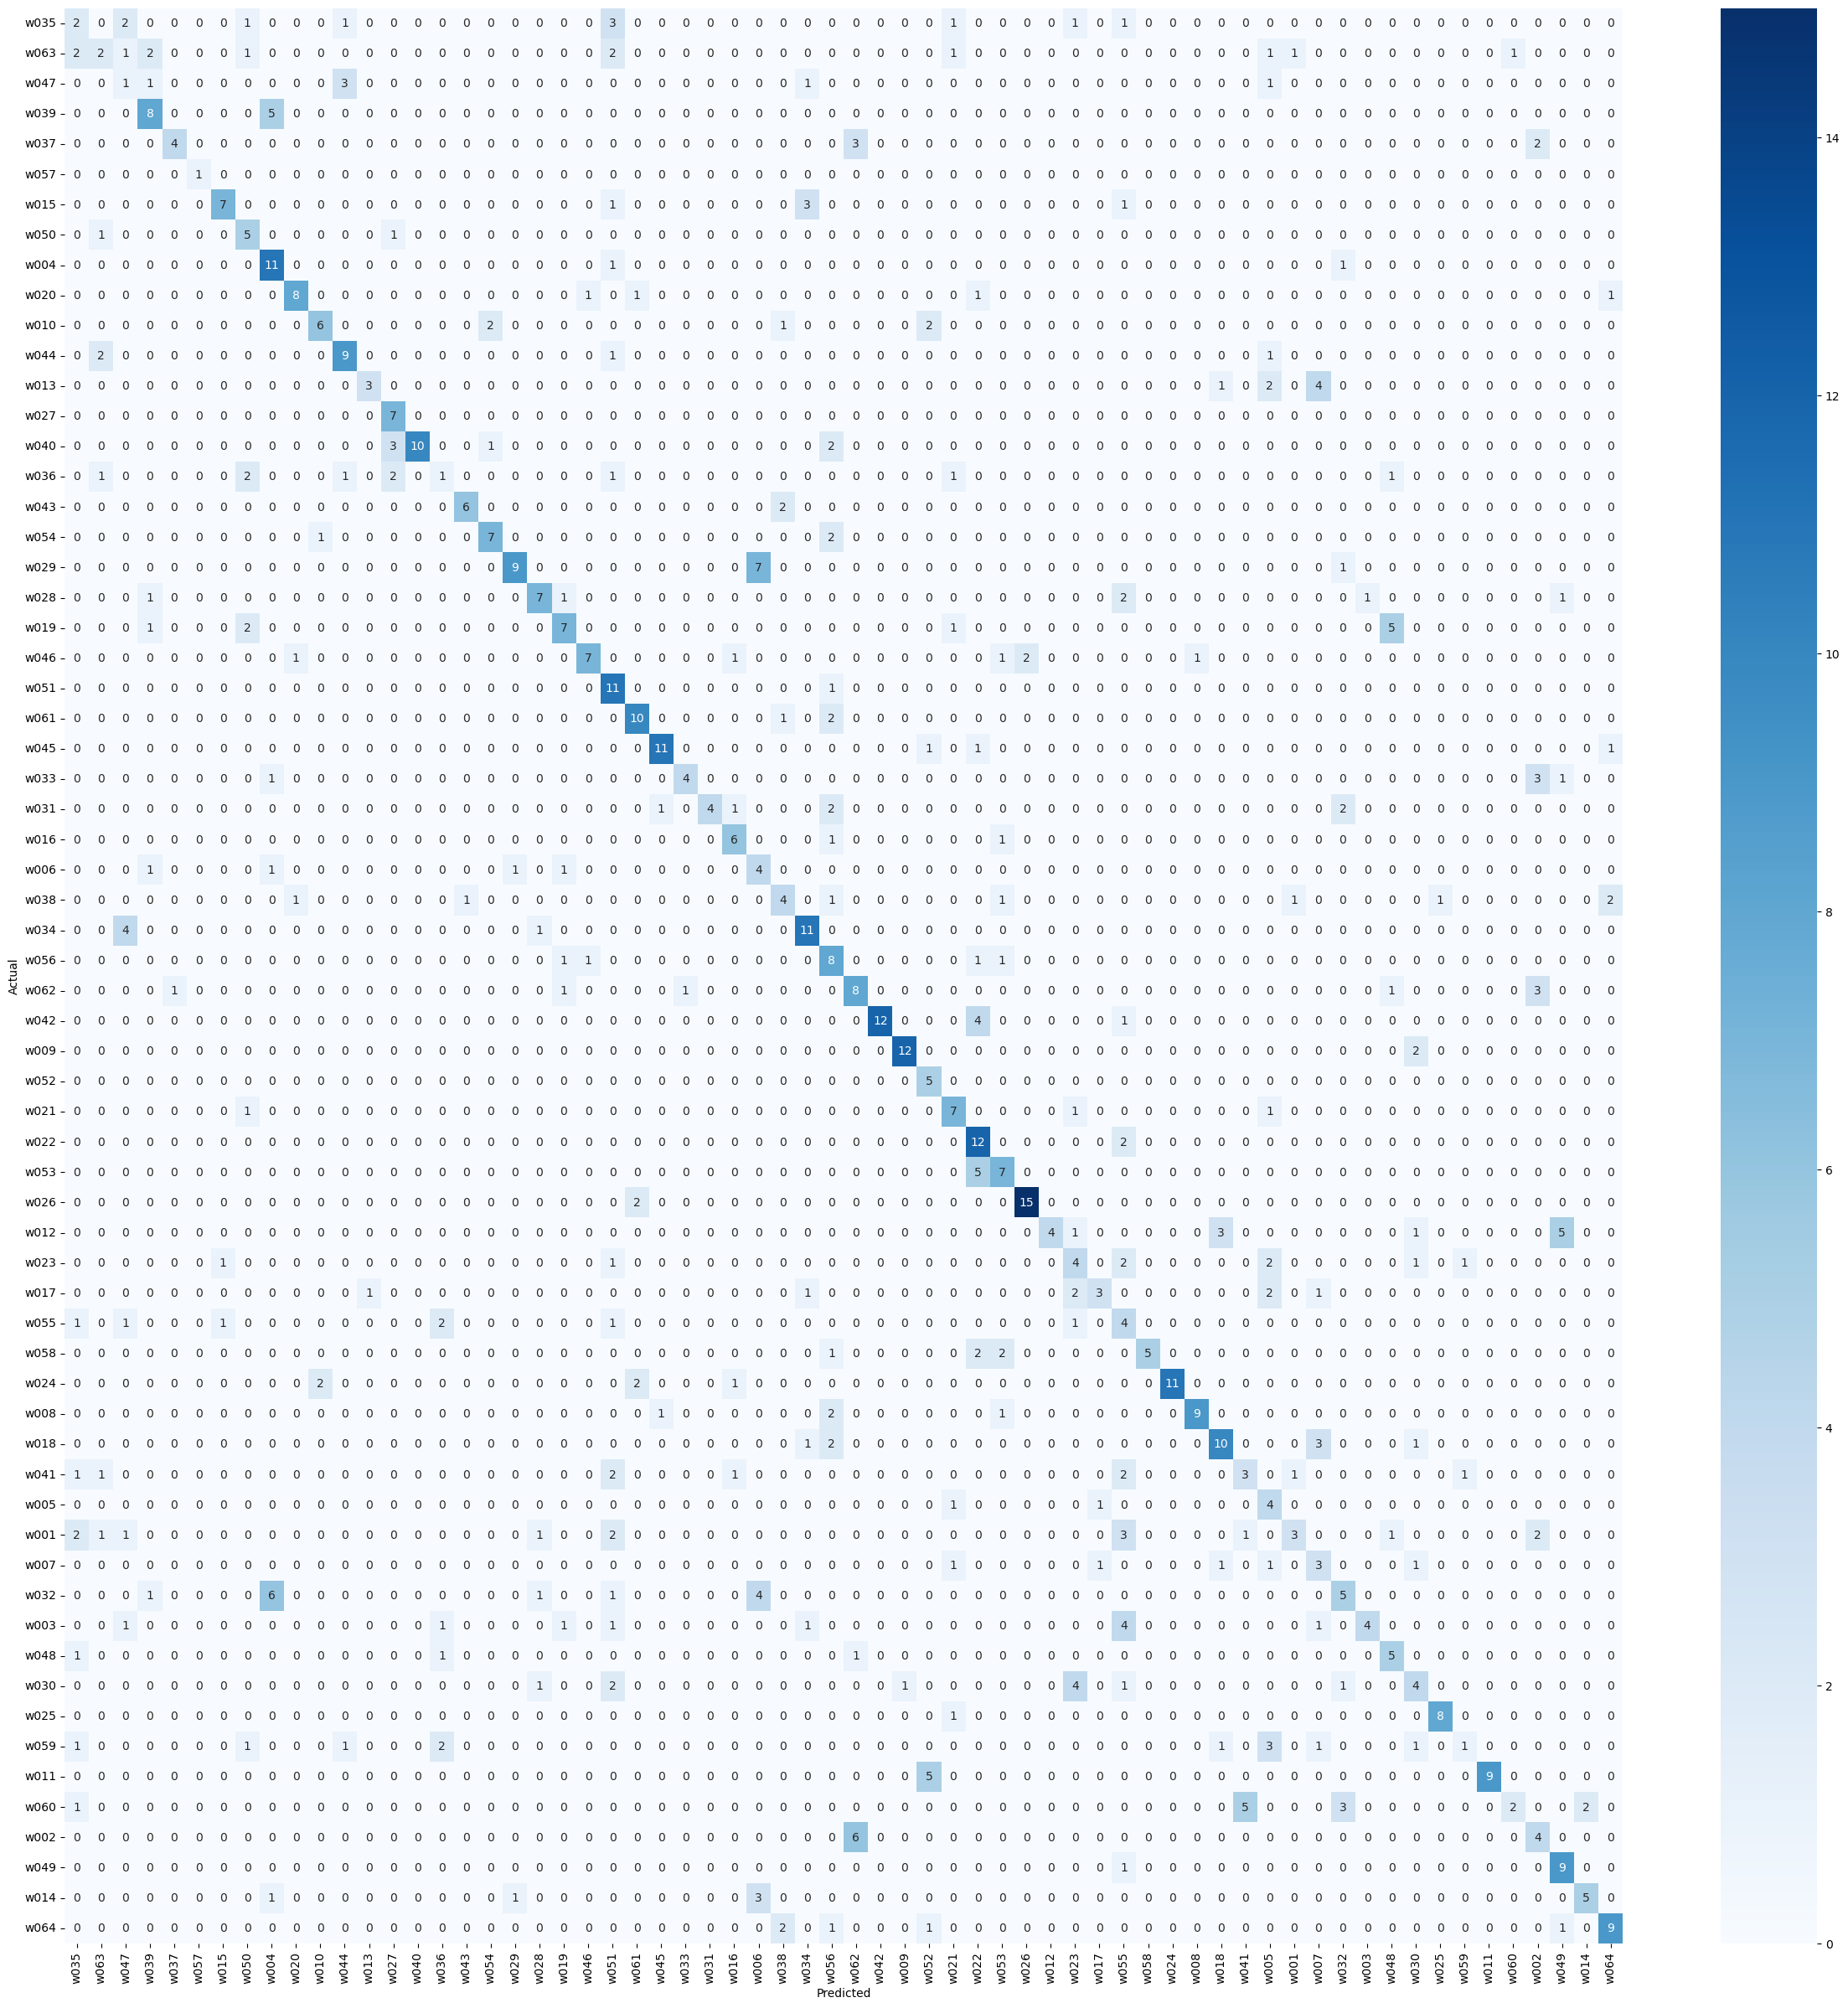

In [73]:
exp_number = 13
description = """
64 class SSL dataset, each class having average 6 training and many for vali/testing. This uses 61 landmarks found through the experiments
Average results after 3 runs  130 Epoch without early stopping.  0.45 mins each training time 

pose_indices_1 = [0, 2, 5, 7, 8, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
hand_indices_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

Average F1 Score: 0.5344
Average Precision: 0.6062
Average Recall: 0.5398
Average Accuracy: 0.5398


Average number of instance per class in traning set
5.890625
"""
result_dir = '../Results/exp_'

# create folder to store results and store results if folder is already there, show error
if not os.path.exists(result_dir + str(exp_number)):
    os.makedirs(result_dir + str(exp_number))

    with open(result_dir + str(exp_number) + '/description.txt', 'w') as f:
        f.write(description)

    # also save plots
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.savefig(result_dir + str(exp_number) + '/accuracy.png')

    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    cm = confusion_matrix(y_test.argmax(axis=1), y_pred_classes)
    plt.figure(figsize=(30, 30))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(top_classes), yticklabels=set(top_classes))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(result_dir + str(exp_number) + '/confusion_matrix.png')


else:
    print("Folder already exists")
